# Car Recognition
## Computer Vision Block — Model 1

**Dataset:** Stanford Car Dataset by Classes Folder (Kaggle – jutrera)

**Goal:** Classify a car photo into one of 196 make/model/year classes and extract `brand` and `model_year` to feed into the ML price prediction block.

**Integration:** `Car photo → CV (recognition) → brand + model_year → ML block (price prediction)`

**Class name format:** Each folder is named `{Make} {Model} {Year}`, e.g. `BMW 3 Series Sedan 2012`. Brand and year are parsed directly from the predicted class name.

## Project Setup
### Libraries and Settings

In [1]:
!pip install -q transformers accelerate evaluate datasets pillow scikit-learn torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 77.4 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
c

In [2]:
import io
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import torch
from PIL import Image
from tqdm import tqdm

from datasets import load_dataset, DatasetDict
from transformers import (
    AutoImageProcessor,
    ViTForImageClassification,
    Trainer,
    TrainingArguments,
    pipeline
)
import evaluate
from sklearn.metrics import accuracy_score, classification_report

import warnings
warnings.filterwarnings('ignore')

print('GPU available:', torch.cuda.is_available())

GPU available: True


## 1. Data Loading and Inspection

**Data source:** [Stanford Car Dataset by Classes Folder](https://www.kaggle.com/datasets/jutrera/stanford-car-dataset-by-classes-folder)

Attach to your Kaggle notebook via **'+ Add Input'**.

In [3]:
# Explore folder structure first
for root, dirs, files in os.walk('/kaggle/input'):
    level = root.replace('/kaggle/input', '').count(os.sep)
    if level < 3:
        print('  ' * level + os.path.basename(root) + '/')
        for f in files[:2]:
            print('  ' * (level + 1) + f)

input/
  datasets/
    jutrera/


In [4]:
# Load dataset — imagefolder assigns labels from subfolder names
# Adjust DATA_ROOT if the printed path above differs
DATA_ROOT = '/kaggle/input/datasets/jutrera/stanford-car-dataset-by-classes-folder'

dataset = load_dataset('imagefolder', data_dir=DATA_ROOT)
dataset

Resolving data files:   0%|          | 0/8144 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/8041 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 8144
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 8041
    })
})

In [5]:
# Class names — each is "{Make} {Model} {Year}"
class_names = dataset['train'].features['label'].names
NUM_LABELS  = len(class_names)
label2id    = {name: i for i, name in enumerate(class_names)}
id2label    = {i: name for i, name in enumerate(class_names)}

print(f'Total classes: {NUM_LABELS}')
print('Example class names:', class_names[:5])

Total classes: 196
Example class names: ['AM General Hummer SUV 2000', 'Acura Integra Type R 2001', 'Acura RL Sedan 2012', 'Acura TL Sedan 2012', 'Acura TL Type-S 2008']


In [6]:
# Helper: parse brand and model_year from a class name string
def parse_class(class_name):
    """
    Input:  'BMW 3 Series Sedan 2012'
    Output: brand='BMW', model_year=2012
    """
    brand = class_name.split()[0]
    year_match = re.search(r'(\d{4})$', class_name.strip())
    model_year = int(year_match.group(1)) if year_match else None
    return brand, model_year

# Test the parser
for name in class_names[:5]:
    brand, year = parse_class(name)
    print(f'  {name!r:40s} → brand={brand!r}, model_year={year}')

  'AM General Hummer SUV 2000'             → brand='AM', model_year=2000
  'Acura Integra Type R 2001'              → brand='Acura', model_year=2001
  'Acura RL Sedan 2012'                    → brand='Acura', model_year=2012
  'Acura TL Sedan 2012'                    → brand='Acura', model_year=2012
  'Acura TL Type-S 2008'                   → brand='Acura', model_year=2008


In [7]:
# Use the pre-existing train/test split from the dataset if available
# Otherwise create one manually
if 'test' in dataset:
    split = dataset['train'].train_test_split(test_size=0.15, seed=42)
    our_dataset = DatasetDict({
        'train':      split['train'],
        'validation': split['test'],
        'test':       dataset['test']
    })
else:
    split = dataset['train'].train_test_split(test_size=0.3, seed=42)
    val_test = split['test'].train_test_split(test_size=0.5, seed=42)
    our_dataset = DatasetDict({
        'train':      split['train'],
        'validation': val_test['train'],
        'test':       val_test['test']
    })

our_dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 6922
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 1222
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 8041
    })
})

## 2. Exploratory Data Analysis (EDA)

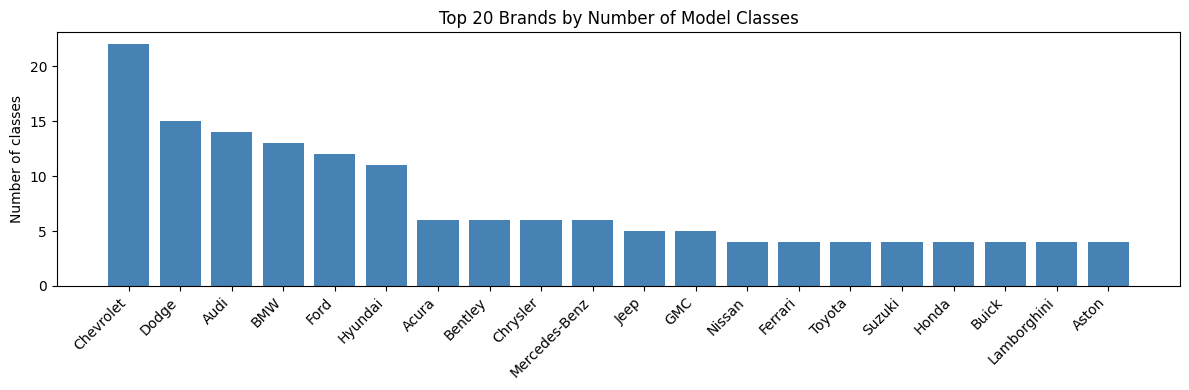

In [8]:
# Distribution of unique brands
brands = [parse_class(name)[0] for name in class_names]
unique_brands, counts = np.unique(brands, return_counts=True)
sorted_idx = np.argsort(counts)[::-1]

plt.figure(figsize=(12, 4))
plt.bar(unique_brands[sorted_idx[:20]], counts[sorted_idx[:20]], color='steelblue')
plt.title('Top 20 Brands by Number of Model Classes')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Number of classes')
plt.tight_layout()
plt.show()

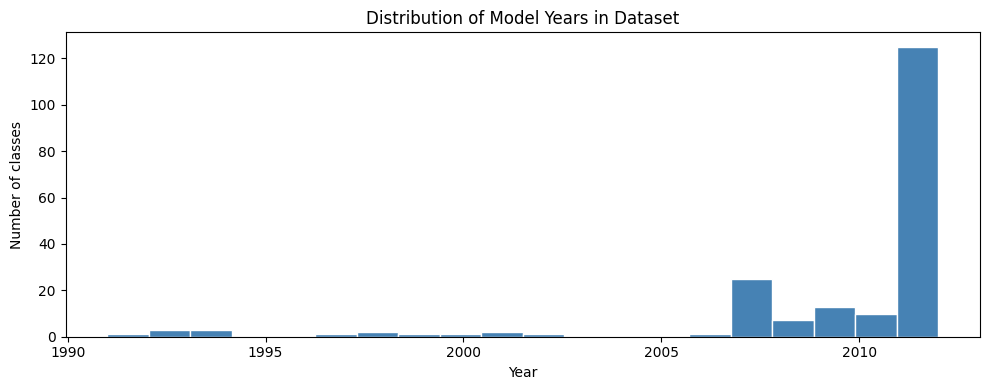

In [9]:
# Distribution of model years across classes
years = [parse_class(name)[1] for name in class_names if parse_class(name)[1]]
plt.figure(figsize=(10, 4))
plt.hist(years, bins=20, color='steelblue', edgecolor='white')
plt.title('Distribution of Model Years in Dataset')
plt.xlabel('Year')
plt.ylabel('Number of classes')
plt.tight_layout()
plt.show()

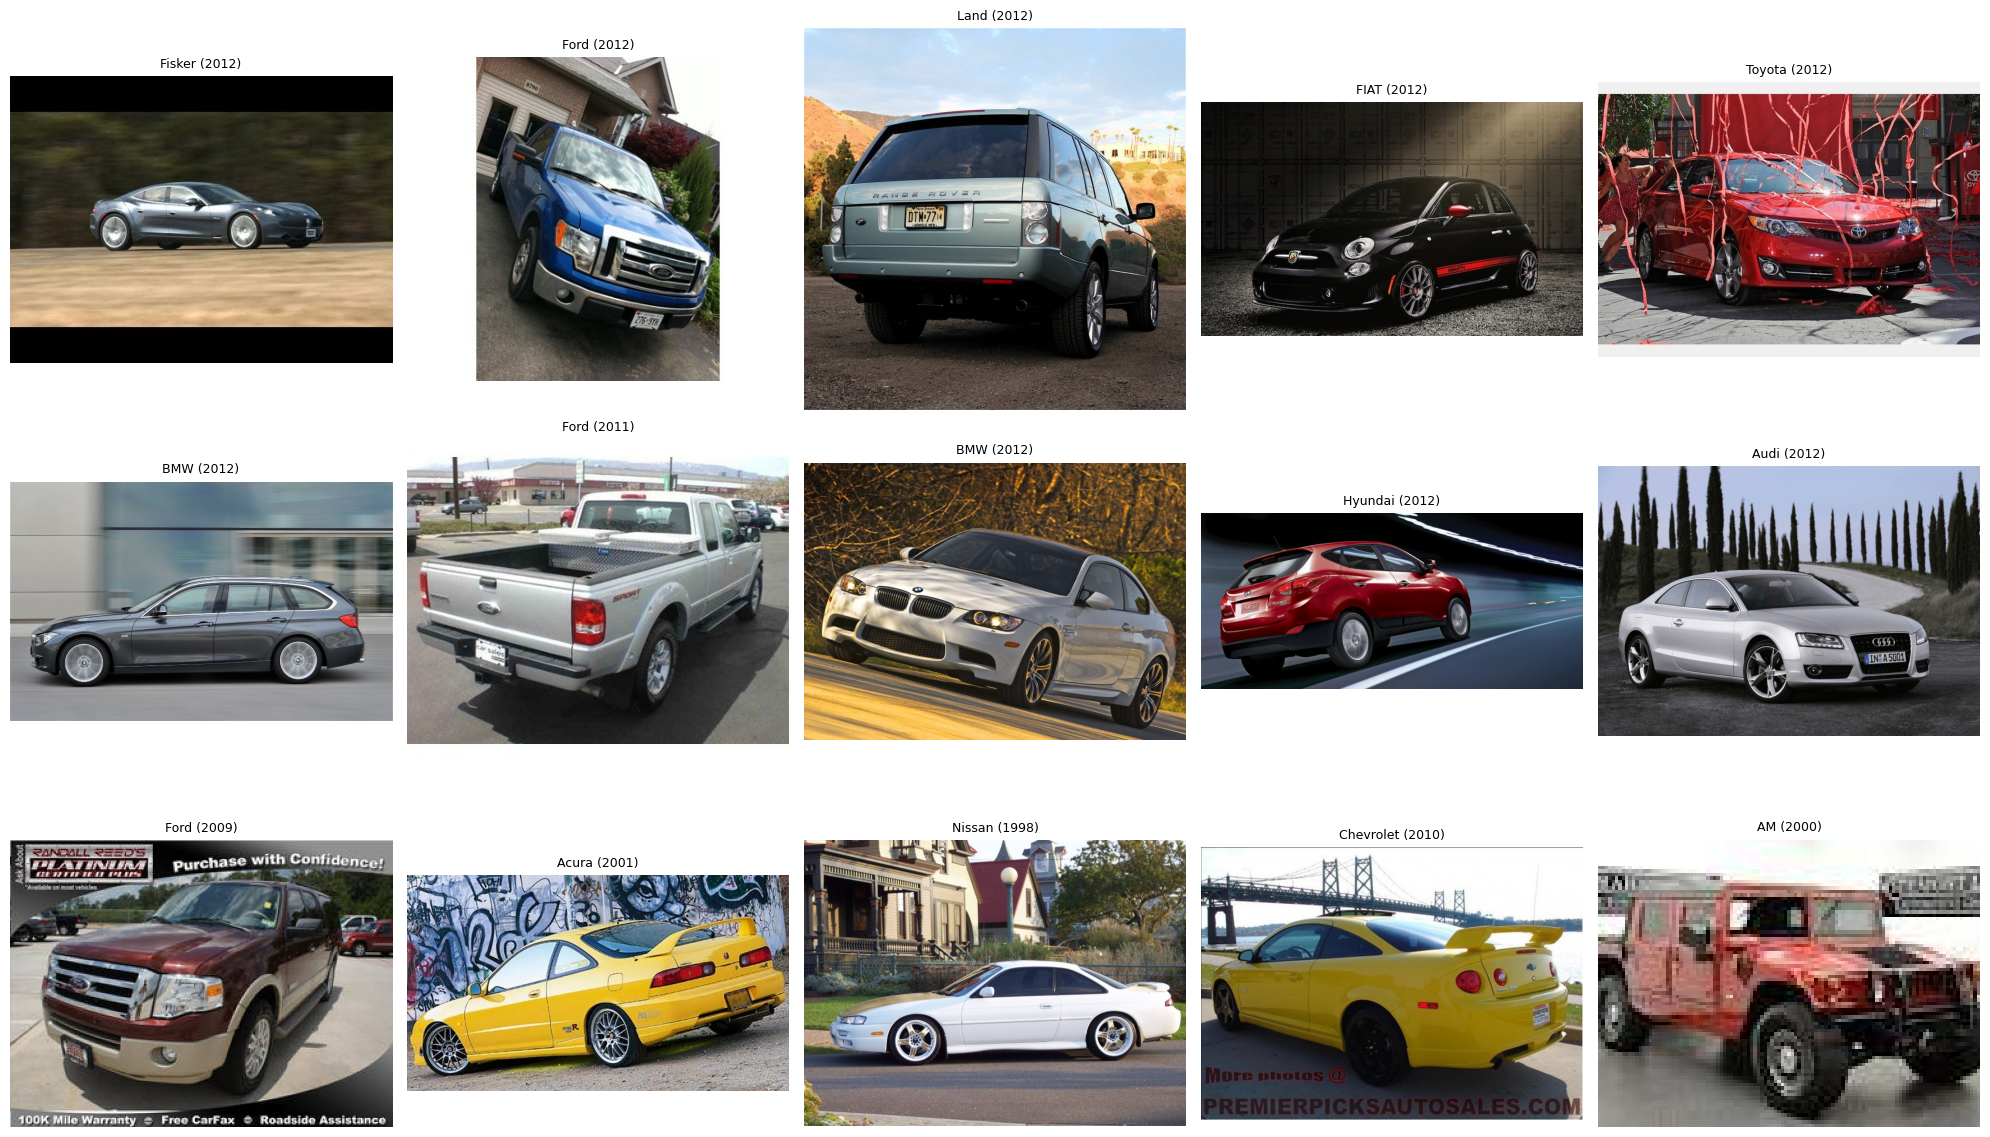

In [10]:
# Sample images from training set
def show_samples(ds, rows, cols):
    samples = ds.shuffle(seed=42).select(np.arange(rows * cols))
    fig = plt.figure(figsize=(cols * 4, rows * 4))
    for i in range(rows * cols):
        img = samples[i]['image']
        if not hasattr(img, 'convert'):
            img = Image.open(io.BytesIO(img['bytes']))
        label = id2label[samples[i]['label']]
        brand, year = parse_class(label)
        fig.add_subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.title(f'{brand} ({year})', fontsize=9)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_samples(our_dataset['train'], rows=3, cols=5)

## 3. Preprocessing

Using `AutoImageProcessor` from `google/vit-base-patch16-224` — resizes to 224×224 and normalises pixel values, identical to the damage assessment notebook.

In [11]:
processor = AutoImageProcessor.from_pretrained('google/vit-base-patch16-224')

def transforms(batch):
    images = [img.convert('RGB') if hasattr(img, 'convert')
              else Image.open(io.BytesIO(img['bytes'])).convert('RGB')
              for img in batch['image']]
    inputs = processor(images, return_tensors='pt')
    inputs['labels'] = batch['label']
    return inputs

from torchvision import transforms as T
augmentation = T.Compose([
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    T.RandomRotation(10),
])

def transforms_augmented(batch):
    images = [img.convert('RGB') if hasattr(img, 'convert')
              else Image.open(io.BytesIO(img['bytes'])).convert('RGB')
              for img in batch['image']]
    images = [augmentation(img) for img in images]
    inputs = processor(images, return_tensors='pt')
    inputs['labels'] = batch['label']
    return inputs

def collate_fn(batch):
    return {
        'pixel_values': torch.stack([x['pixel_values'] for x in batch]),
        'labels': torch.tensor([x['labels'] for x in batch])
    }

accuracy_metric = evaluate.load('accuracy')
def compute_metrics(eval_preds):
    logits, labels = eval_preds
    predictions = np.argmax(logits, axis=1)
    return accuracy_metric.compute(predictions=predictions, references=labels)

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


---
## Iteration 1 — Zero-Shot Baseline with CLIP

**Objective:** Establish a zero-shot baseline for brand recognition using CLIP. Candidate labels are the unique car brands (not all 196 classes — that would be too many for CLIP).

**Model:** `openai/clip-vit-large-patch14` (same checkpoint as Week 7 exercise)

**Metric:** Brand-level accuracy (correct if predicted brand matches true brand).

In [12]:
clip_detector = pipeline(
    model='openai/clip-vit-large-patch14',
    task='zero-shot-image-classification'
)

# Use brand names as candidate labels (simpler than 196 classes)
unique_brands_list = sorted(list(set(brands)))
candidate_labels_clip = [f'a photo of a {b} car' for b in unique_brands_list]
print(f'Number of candidate labels: {len(candidate_labels_clip)}')
print('Example:', candidate_labels_clip[:3])

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/905 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Number of candidate labels: 49
Example: ['a photo of a AM car', 'a photo of a Acura car', 'a photo of a Aston car']


In [13]:
# Evaluate CLIP on brand recognition (test sample)
test_sample = our_dataset['test'].shuffle(seed=42).select(range(min(150, len(our_dataset['test']))))

true_brands_clip = []
pred_brands_clip = []

for sample in tqdm(test_sample):
    img = sample['image']
    if not hasattr(img, 'convert'):
        img = Image.open(io.BytesIO(img['bytes']))
    results = clip_detector(img, candidate_labels=candidate_labels_clip)
    pred_label = max(results, key=lambda x: x['score'])['label']
    pred_brand = pred_label.replace('a photo of a ', '').replace(' car', '')
    true_brand = parse_class(id2label[sample['label']])[0]
    true_brands_clip.append(true_brand)
    pred_brands_clip.append(pred_brand)

clip_brand_acc = accuracy_score(true_brands_clip, pred_brands_clip)
print(f'CLIP Zero-Shot Brand Accuracy: {clip_brand_acc:.4f}')

100%|██████████| 150/150 [00:19<00:00,  7.59it/s]

CLIP Zero-Shot Brand Accuracy: 0.7333


---
## Iteration 2 — Transfer Learning: ViT with Frozen Backbone

**Objective:** Fine-tune only the classification head of ViT on all 196 Stanford Cars classes.

**Model:** `google/vit-base-patch16-224` — same as Week 6 exercise.

**Key changes vs Iteration 1:** Task-specific supervised training; 196-class full classification (brand + model + year).

In [14]:
processed_dataset = our_dataset.with_transform(transforms)

In [15]:
vit_iter2 = ViTForImageClassification.from_pretrained(
    'google/vit-base-patch16-224',
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

# Freeze all layers except the classifier head
for name, p in vit_iter2.named_parameters():
    if not name.startswith('classifier'):
        p.requires_grad = False

num_params       = sum(p.numel() for p in vit_iter2.parameters())
trainable_params = sum(p.numel() for p in vit_iter2.parameters() if p.requires_grad)
print(f'{num_params = :,} | {trainable_params = :,}')

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([196])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([196, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


num_params = 85,949,380 | trainable_params = 150,724


In [16]:
training_args_iter2 = TrainingArguments(
    output_dir='./vit-cars-iter2',
    per_device_train_batch_size=16,
    num_train_epochs=5,
    learning_rate=3e-4,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    remove_unused_columns=False,
    logging_steps=50,
    report_to='none',
    disable_tqdm=True
)

trainer_iter2 = Trainer(
    model=vit_iter2,
    args=training_args_iter2,
    data_collator=collate_fn,
    compute_metrics=compute_metrics,
    train_dataset=processed_dataset['train'],
    eval_dataset=processed_dataset['validation'],
    processing_class=processor
)

trainer_iter2.train()

{'loss': '5.162', 'grad_norm': '4.873', 'learning_rate': '0.0002865', 'epoch': '0.2304'}
{'loss': '4.531', 'grad_norm': '4.622', 'learning_rate': '0.0002726', 'epoch': '0.4608'}
{'loss': '4.148', 'grad_norm': '4.29', 'learning_rate': '0.0002588', 'epoch': '0.6912'}
{'loss': '3.882', 'grad_norm': '4.294', 'learning_rate': '0.000245', 'epoch': '0.9217'}
{'eval_loss': '3.672', 'eval_accuracy': '0.1817', 'eval_runtime': '31.9', 'eval_samples_per_second': '38.31', 'eval_steps_per_second': '2.414', 'epoch': '1'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '3.566', 'grad_norm': '4.209', 'learning_rate': '0.0002312', 'epoch': '1.152'}
{'loss': '3.366', 'grad_norm': '4.15', 'learning_rate': '0.0002173', 'epoch': '1.382'}
{'loss': '3.302', 'grad_norm': '4.272', 'learning_rate': '0.0002035', 'epoch': '1.613'}
{'loss': '3.188', 'grad_norm': '3.93', 'learning_rate': '0.0001897', 'epoch': '1.843'}
{'eval_loss': '3.215', 'eval_accuracy': '0.2799', 'eval_runtime': '21.39', 'eval_samples_per_second': '57.12', 'eval_steps_per_second': '3.6', 'epoch': '2'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '3.106', 'grad_norm': '4.029', 'learning_rate': '0.0001759', 'epoch': '2.074'}
{'loss': '2.921', 'grad_norm': '3.933', 'learning_rate': '0.000162', 'epoch': '2.304'}
{'loss': '2.917', 'grad_norm': '3.926', 'learning_rate': '0.0001482', 'epoch': '2.535'}
{'loss': '2.837', 'grad_norm': '4.261', 'learning_rate': '0.0001344', 'epoch': '2.765'}
{'loss': '2.763', 'grad_norm': '4.124', 'learning_rate': '0.0001206', 'epoch': '2.995'}
{'eval_loss': '2.999', 'eval_accuracy': '0.3241', 'eval_runtime': '21.04', 'eval_samples_per_second': '58.09', 'eval_steps_per_second': '3.661', 'epoch': '3'}


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '2.541', 'grad_norm': '4.175', 'learning_rate': '5.143e-05', 'epoch': '4.147'}
{'loss': '2.5', 'grad_norm': '3.625', 'learning_rate': '3.76e-05', 'epoch': '4.378'}
{'loss': '2.521', 'grad_norm': '3.722', 'learning_rate': '2.378e-05', 'epoch': '4.608'}
{'loss': '2.549', 'grad_norm': '3.813', 'learning_rate': '9.954e-06', 'epoch': '4.839'}
{'eval_loss': '2.871', 'eval_accuracy': '0.3494', 'eval_runtime': '20.8', 'eval_samples_per_second': '58.75', 'eval_steps_per_second': '3.702', 'epoch': '5'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '852.6', 'train_samples_per_second': '40.59', 'train_steps_per_second': '1.273', 'train_loss': '3.142', 'epoch': '5'}


TrainOutput(global_step=1085, training_loss=3.1423360938850085, metrics={'train_runtime': 852.594, 'train_samples_per_second': 40.594, 'train_steps_per_second': 1.273, 'train_loss': 3.1423360938850085, 'epoch': 5.0})

In [17]:
results_iter2 = trainer_iter2.evaluate(processed_dataset['test'])
print('Iteration 2 Test Results:', results_iter2)

preds_iter2  = trainer_iter2.predict(processed_dataset['test'])
y_pred_iter2 = preds_iter2.predictions.argmax(axis=1)
y_true       = preds_iter2.label_ids

# Brand-level accuracy (more meaningful than 196-class accuracy)
true_brands_iter2 = [parse_class(id2label[l])[0] for l in y_true]
pred_brands_iter2 = [parse_class(id2label[p])[0] for p in y_pred_iter2]
brand_acc_iter2   = accuracy_score(true_brands_iter2, pred_brands_iter2)

print(f'Class accuracy (196 classes): {results_iter2["eval_accuracy"]:.4f}')
print(f'Brand accuracy:               {brand_acc_iter2:.4f}')

{'eval_loss': '2.869', 'eval_accuracy': '0.3569', 'eval_runtime': '210', 'eval_samples_per_second': '38.3', 'eval_steps_per_second': '2.396', 'epoch': '5'}
Iteration 2 Test Results: {'eval_loss': 2.8690683841705322, 'eval_accuracy': 0.3569207809973884, 'eval_runtime': 209.9623, 'eval_samples_per_second': 38.297, 'eval_steps_per_second': 2.396, 'epoch': 5.0}
Class accuracy (196 classes): 0.3569
Brand accuracy:               0.4565


---
## Iteration 3 — Transfer Learning: ViT with Partial Unfreeze + Augmentation

**Objective:** Unfreeze the last 2 transformer encoder blocks and add augmentation to improve generalisation across car models.

**Key changes vs Iteration 2:** Encoder layers 10 and 11 unfrozen; random flip, colour jitter, and rotation augmentation added.

In [18]:
processed_train_aug = our_dataset['train'].with_transform(transforms_augmented)
processed_val_test  = our_dataset.with_transform(transforms)

In [19]:
vit_iter3 = ViTForImageClassification.from_pretrained(
    'google/vit-base-patch16-224',
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

for name, p in vit_iter3.named_parameters():
    p.requires_grad = False

for name, p in vit_iter3.named_parameters():
    if ('encoder.layer.10' in name or
        'encoder.layer.11' in name or
        name.startswith('classifier')):
        p.requires_grad = True

num_params       = sum(p.numel() for p in vit_iter3.parameters())
trainable_params = sum(p.numel() for p in vit_iter3.parameters() if p.requires_grad)
print(f'{num_params = :,} | {trainable_params = :,}')

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([196])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([196, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


num_params = 85,949,380 | trainable_params = 14,326,468


In [20]:
training_args_iter3 = TrainingArguments(
    output_dir='./vit-cars-iter3',
    per_device_train_batch_size=16,
    num_train_epochs=8,
    learning_rate=1e-4,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    remove_unused_columns=False,
    logging_steps=50,
    report_to='none',
    disable_tqdm=True
)

trainer_iter3 = Trainer(
    model=vit_iter3,
    args=training_args_iter3,
    data_collator=collate_fn,
    compute_metrics=compute_metrics,
    train_dataset=processed_train_aug,
    eval_dataset=processed_val_test['validation'],
    processing_class=processor
)

trainer_iter3.train()

{'loss': '5.22', 'grad_norm': '4.91', 'learning_rate': '9.718e-05', 'epoch': '0.2304'}
{'loss': '4.69', 'grad_norm': '5.104', 'learning_rate': '9.43e-05', 'epoch': '0.4608'}
{'loss': '4.221', 'grad_norm': '4.783', 'learning_rate': '9.142e-05', 'epoch': '0.6912'}
{'loss': '3.855', 'grad_norm': '4.819', 'learning_rate': '8.854e-05', 'epoch': '0.9217'}
{'eval_loss': '3.573', 'eval_accuracy': '0.1923', 'eval_runtime': '22.38', 'eval_samples_per_second': '54.6', 'eval_steps_per_second': '3.44', 'epoch': '1'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '3.459', 'grad_norm': '4.824', 'learning_rate': '8.566e-05', 'epoch': '1.152'}
{'loss': '3.198', 'grad_norm': '4.65', 'learning_rate': '8.278e-05', 'epoch': '1.382'}
{'loss': '3.059', 'grad_norm': '4.881', 'learning_rate': '7.99e-05', 'epoch': '1.613'}
{'loss': '2.905', 'grad_norm': '4.445', 'learning_rate': '7.702e-05', 'epoch': '1.843'}
{'eval_loss': '2.807', 'eval_accuracy': '0.3592', 'eval_runtime': '22.07', 'eval_samples_per_second': '55.37', 'eval_steps_per_second': '3.489', 'epoch': '2'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '2.707', 'grad_norm': '4.441', 'learning_rate': '7.414e-05', 'epoch': '2.074'}
{'loss': '2.447', 'grad_norm': '4.274', 'learning_rate': '7.126e-05', 'epoch': '2.304'}
{'loss': '2.358', 'grad_norm': '4.384', 'learning_rate': '6.838e-05', 'epoch': '2.535'}
{'loss': '2.228', 'grad_norm': '4.579', 'learning_rate': '6.55e-05', 'epoch': '2.765'}
{'loss': '2.122', 'grad_norm': '4.869', 'learning_rate': '6.262e-05', 'epoch': '2.995'}
{'eval_loss': '2.329', 'eval_accuracy': '0.4845', 'eval_runtime': '22.35', 'eval_samples_per_second': '54.68', 'eval_steps_per_second': '3.445', 'epoch': '3'}


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.9923', 'grad_norm': '3.564', 'learning_rate': '1.077e-05', 'epoch': '7.143'}
{'loss': '0.9783', 'grad_norm': '4.217', 'learning_rate': '7.892e-06', 'epoch': '7.373'}
{'loss': '0.9593', 'grad_norm': '3.57', 'learning_rate': '5.012e-06', 'epoch': '7.604'}
{'loss': '0.9447', 'grad_norm': '3.428', 'learning_rate': '2.131e-06', 'epoch': '7.834'}
{'eval_loss': '1.622', 'eval_accuracy': '0.6146', 'eval_runtime': '22.34', 'eval_samples_per_second': '54.7', 'eval_steps_per_second': '3.447', 'epoch': '8'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '2355', 'train_samples_per_second': '23.51', 'train_steps_per_second': '0.737', 'train_loss': '2.029', 'epoch': '8'}


TrainOutput(global_step=1736, training_loss=2.0289379726357173, metrics={'train_runtime': 2355.1068, 'train_samples_per_second': 23.513, 'train_steps_per_second': 0.737, 'train_loss': 2.0289379726357173, 'epoch': 8.0})

In [21]:
results_iter3 = trainer_iter3.evaluate(processed_val_test['test'])
print('Iteration 3 Test Results:', results_iter3)

preds_iter3  = trainer_iter3.predict(processed_val_test['test'])
y_pred_iter3 = preds_iter3.predictions.argmax(axis=1)

true_brands_iter3 = [parse_class(id2label[l])[0] for l in y_true]
pred_brands_iter3 = [parse_class(id2label[p])[0] for p in y_pred_iter3]
brand_acc_iter3   = accuracy_score(true_brands_iter3, pred_brands_iter3)

print(f'Class accuracy (196 classes): {results_iter3["eval_accuracy"]:.4f}')
print(f'Brand accuracy:               {brand_acc_iter3:.4f}')

{'eval_loss': '1.599', 'eval_accuracy': '0.628', 'eval_runtime': '154.7', 'eval_samples_per_second': '51.97', 'eval_steps_per_second': '3.251', 'epoch': '8'}
Iteration 3 Test Results: {'eval_loss': 1.5988438129425049, 'eval_accuracy': 0.6280313393856486, 'eval_runtime': 154.7226, 'eval_samples_per_second': 51.97, 'eval_steps_per_second': 3.251, 'epoch': 8.0}
Class accuracy (196 classes): 0.6280
Brand accuracy:               0.7410


In [22]:
# --- Model Comparison Summary ---
print('=== Model Comparison ===')
print(f'Iter 1 – CLIP zero-shot brand accuracy:        {clip_brand_acc:.4f}')
print(f'Iter 2 – ViT frozen backbone class accuracy:   {results_iter2["eval_accuracy"]:.4f}  |  brand: {brand_acc_iter2:.4f}')
print(f'Iter 3 – ViT partial unfreeze + aug accuracy:  {results_iter3["eval_accuracy"]:.4f}  |  brand: {brand_acc_iter3:.4f}')

=== Model Comparison ===
Iter 1 – CLIP zero-shot brand accuracy:        0.7333
Iter 2 – ViT frozen backbone class accuracy:   0.3569  |  brand: 0.4565
Iter 3 – ViT partial unfreeze + aug accuracy:  0.6280  |  brand: 0.7410


## 4. Error Analysis

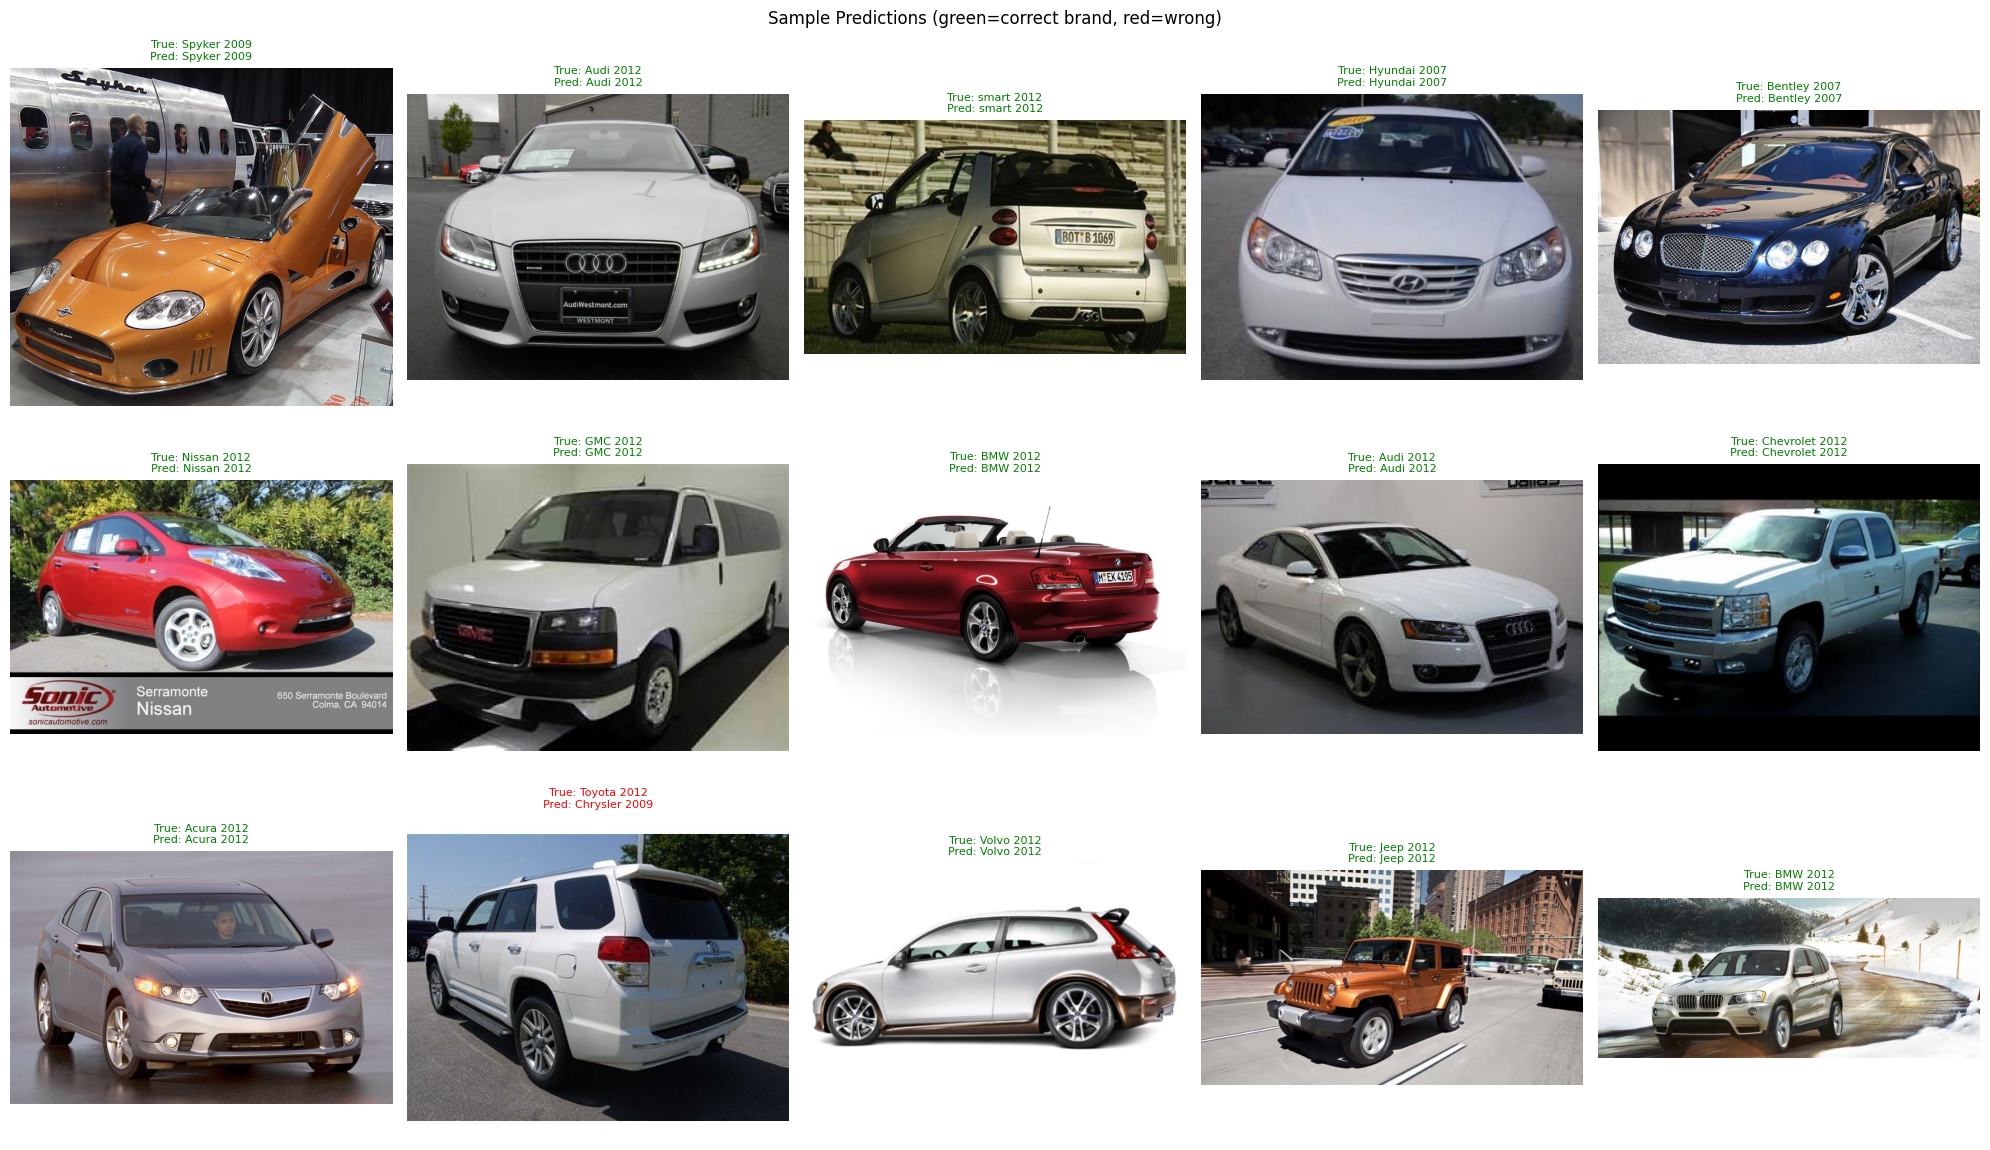

In [23]:
# Visual inspection of predictions — best model (Iter 3)
def show_predictions(rows, cols):
    samples = our_dataset['test'].shuffle(seed=99).select(np.arange(rows * cols))
    processed_samples = samples.with_transform(transforms)
    predictions = trainer_iter3.predict(processed_samples).predictions.argmax(axis=1)
    fig = plt.figure(figsize=(cols * 4, rows * 4))
    for i in range(rows * cols):
        img = samples[i]['image']
        if not hasattr(img, 'convert'):
            img = Image.open(io.BytesIO(img['bytes']))
        true_class = id2label[samples[i]['label']]
        pred_class = id2label[predictions[i]]
        true_brand, true_year = parse_class(true_class)
        pred_brand, pred_year = parse_class(pred_class)
        colour = 'green' if true_brand == pred_brand else 'red'
        fig.add_subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.title(
            f'True: {true_brand} {true_year}\nPred: {pred_brand} {pred_year}',
            color=colour, fontsize=8
        )
        plt.axis('off')
    plt.suptitle('Sample Predictions (green=correct brand, red=wrong)', fontsize=12)
    plt.tight_layout()
    plt.show()

show_predictions(rows=3, cols=5)

## 5. Save Final Model

In [24]:
vit_iter3.save_pretrained('./car_recognition_model')
processor.save_pretrained('./car_recognition_model')
print('Model saved to ./car_recognition_model/')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to ./car_recognition_model/


## 6. Integration Test — Extract brand + model_year from a Single Image

Demonstrates how the ML block calls this function at inference time.

In [25]:
car_recognizer = pipeline(
    task='image-classification',
    model=vit_iter3,
    image_processor=processor
)

def predict_car_identity(image):
    """
    Returns brand (str) and model_year (int) from a car photo.
    These feed directly into the ML price prediction block.
    """
    if isinstance(image, str):
        image = Image.open(image).convert('RGB')
    result = car_recognizer(image)
    top = max(result, key=lambda x: x['score'])
    brand, model_year = parse_class(top['label'])
    print(f'Predicted class: {top["label"]}  (confidence: {top["score"]:.2%})')
    print(f'→ brand: {brand!r},  model_year: {model_year}')
    return brand, model_year

# Test on one image from the test set
sample = our_dataset['test'][0]
img = sample['image']
if not hasattr(img, 'convert'):
    img = Image.open(io.BytesIO(img['bytes']))

brand, year = predict_car_identity(img)
print(f'True class: {id2label[sample["label"]]}')

Predicted class: AM General Hummer SUV 2000  (confidence: 96.98%)
→ brand: 'AM',  model_year: 2000
True class: AM General Hummer SUV 2000
